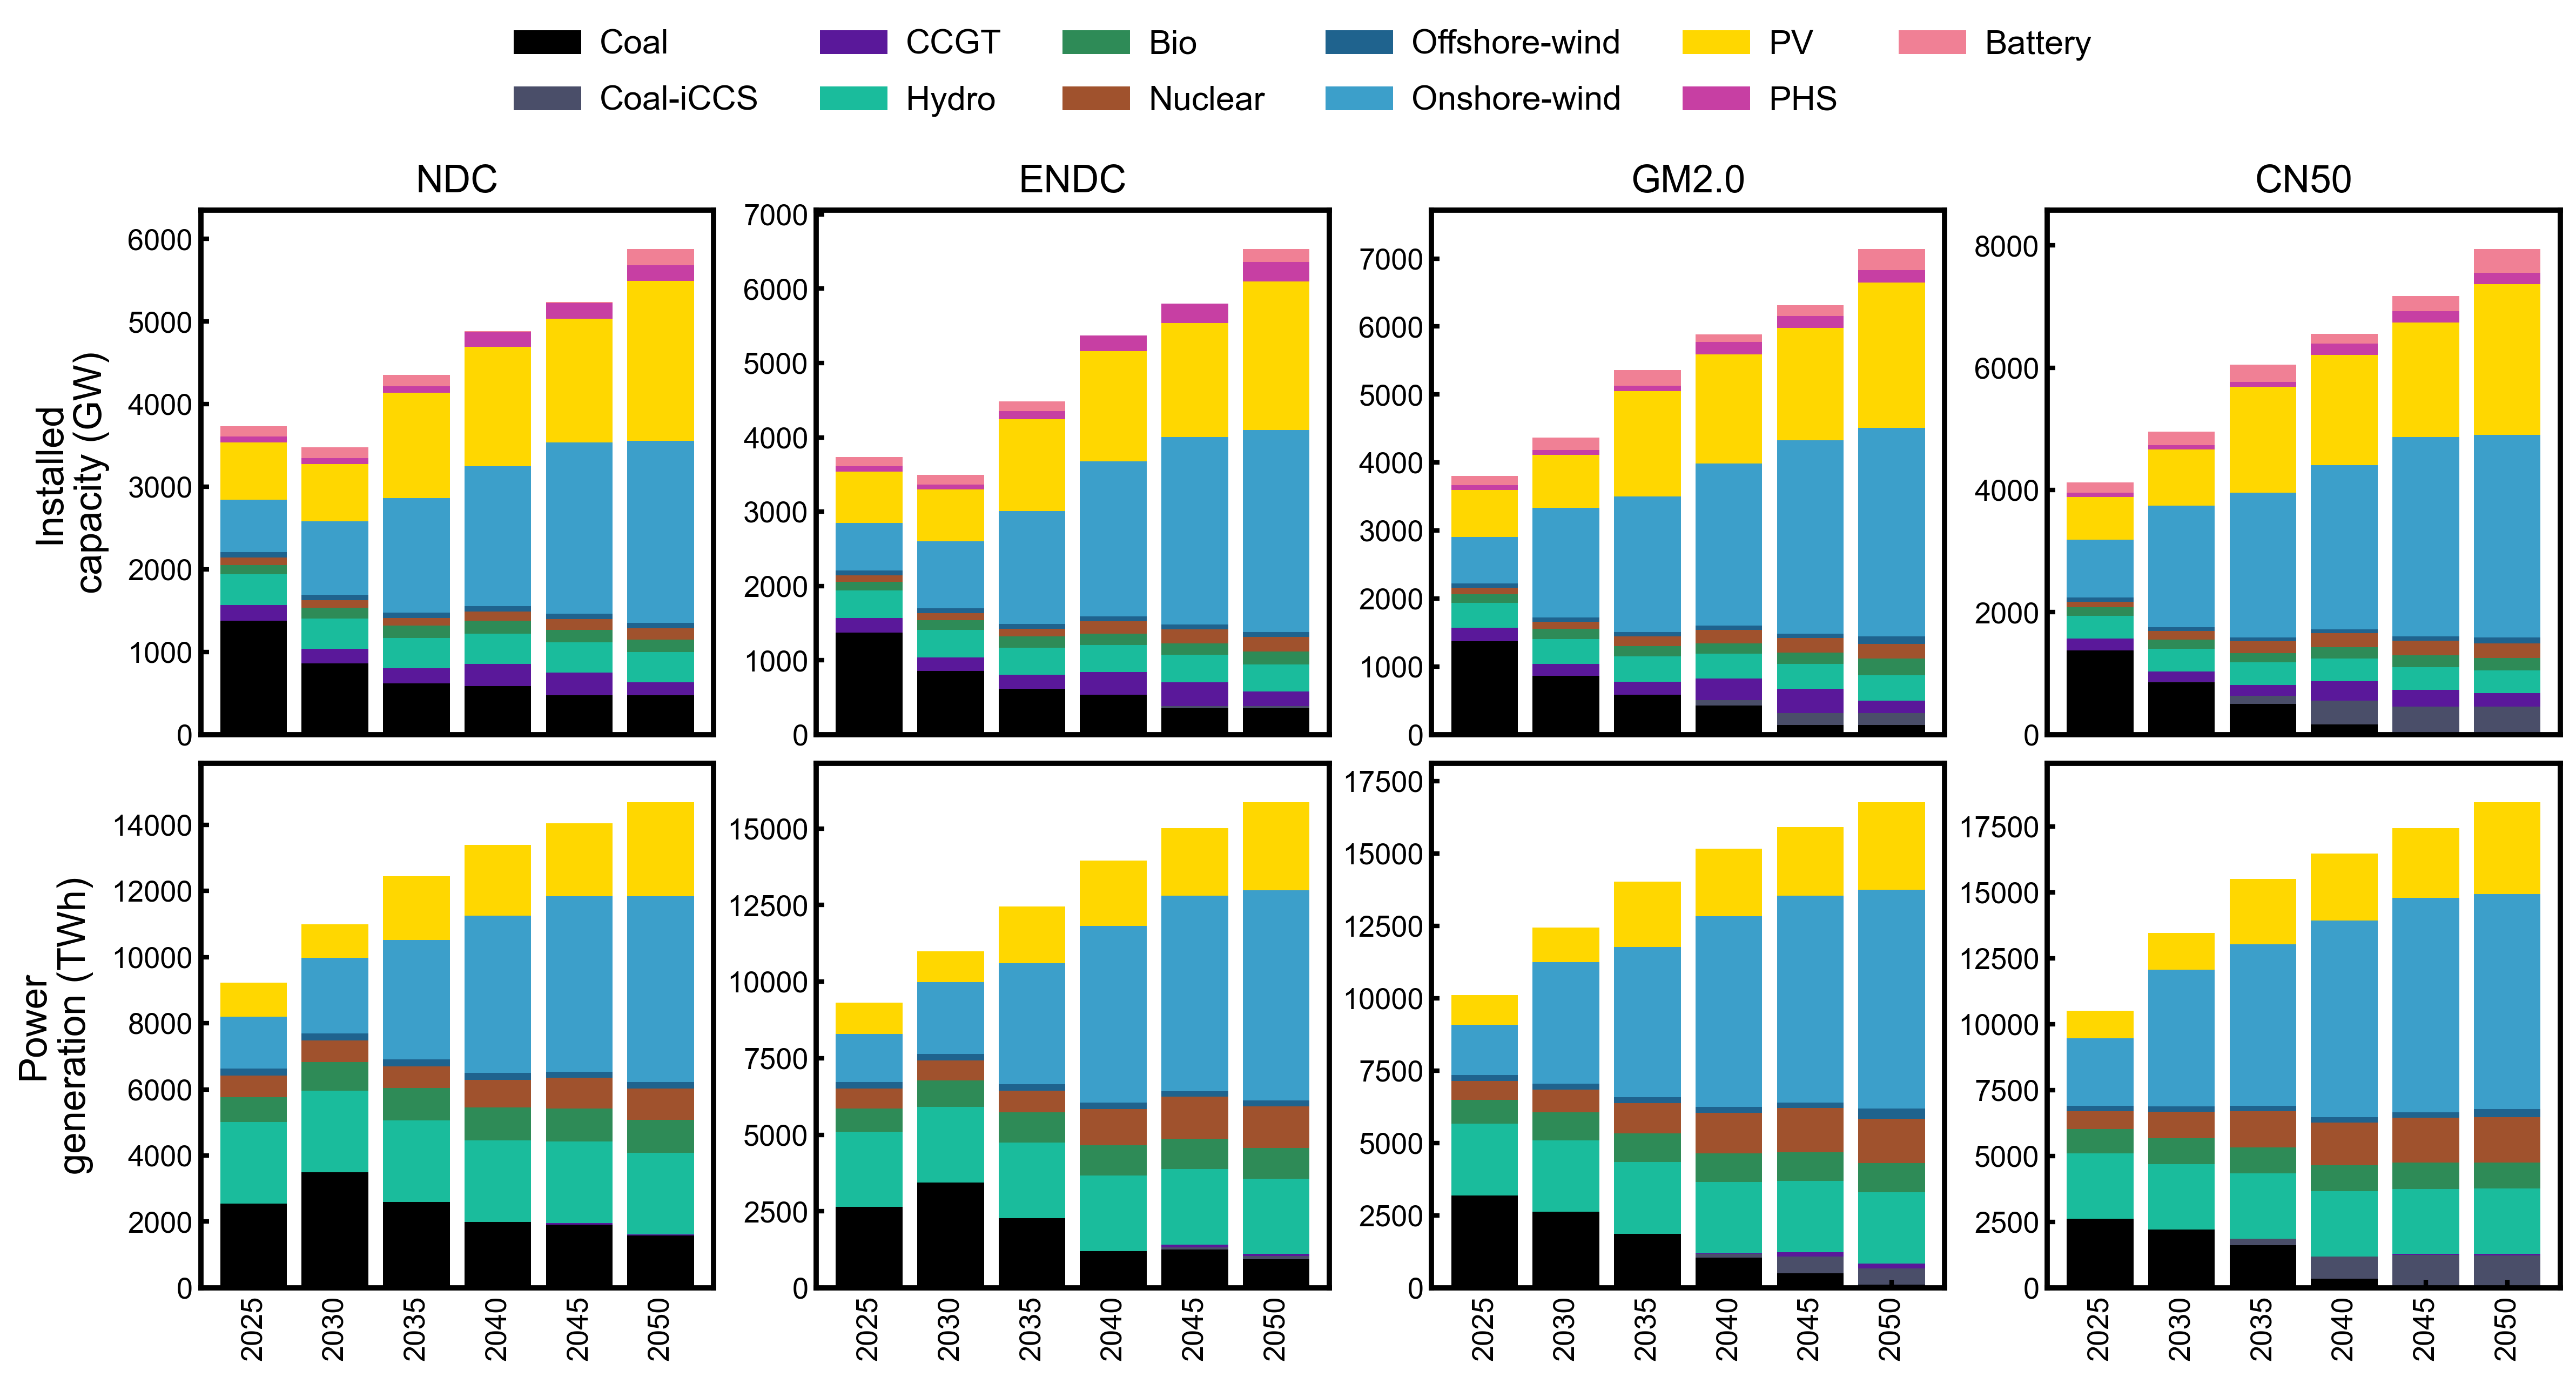

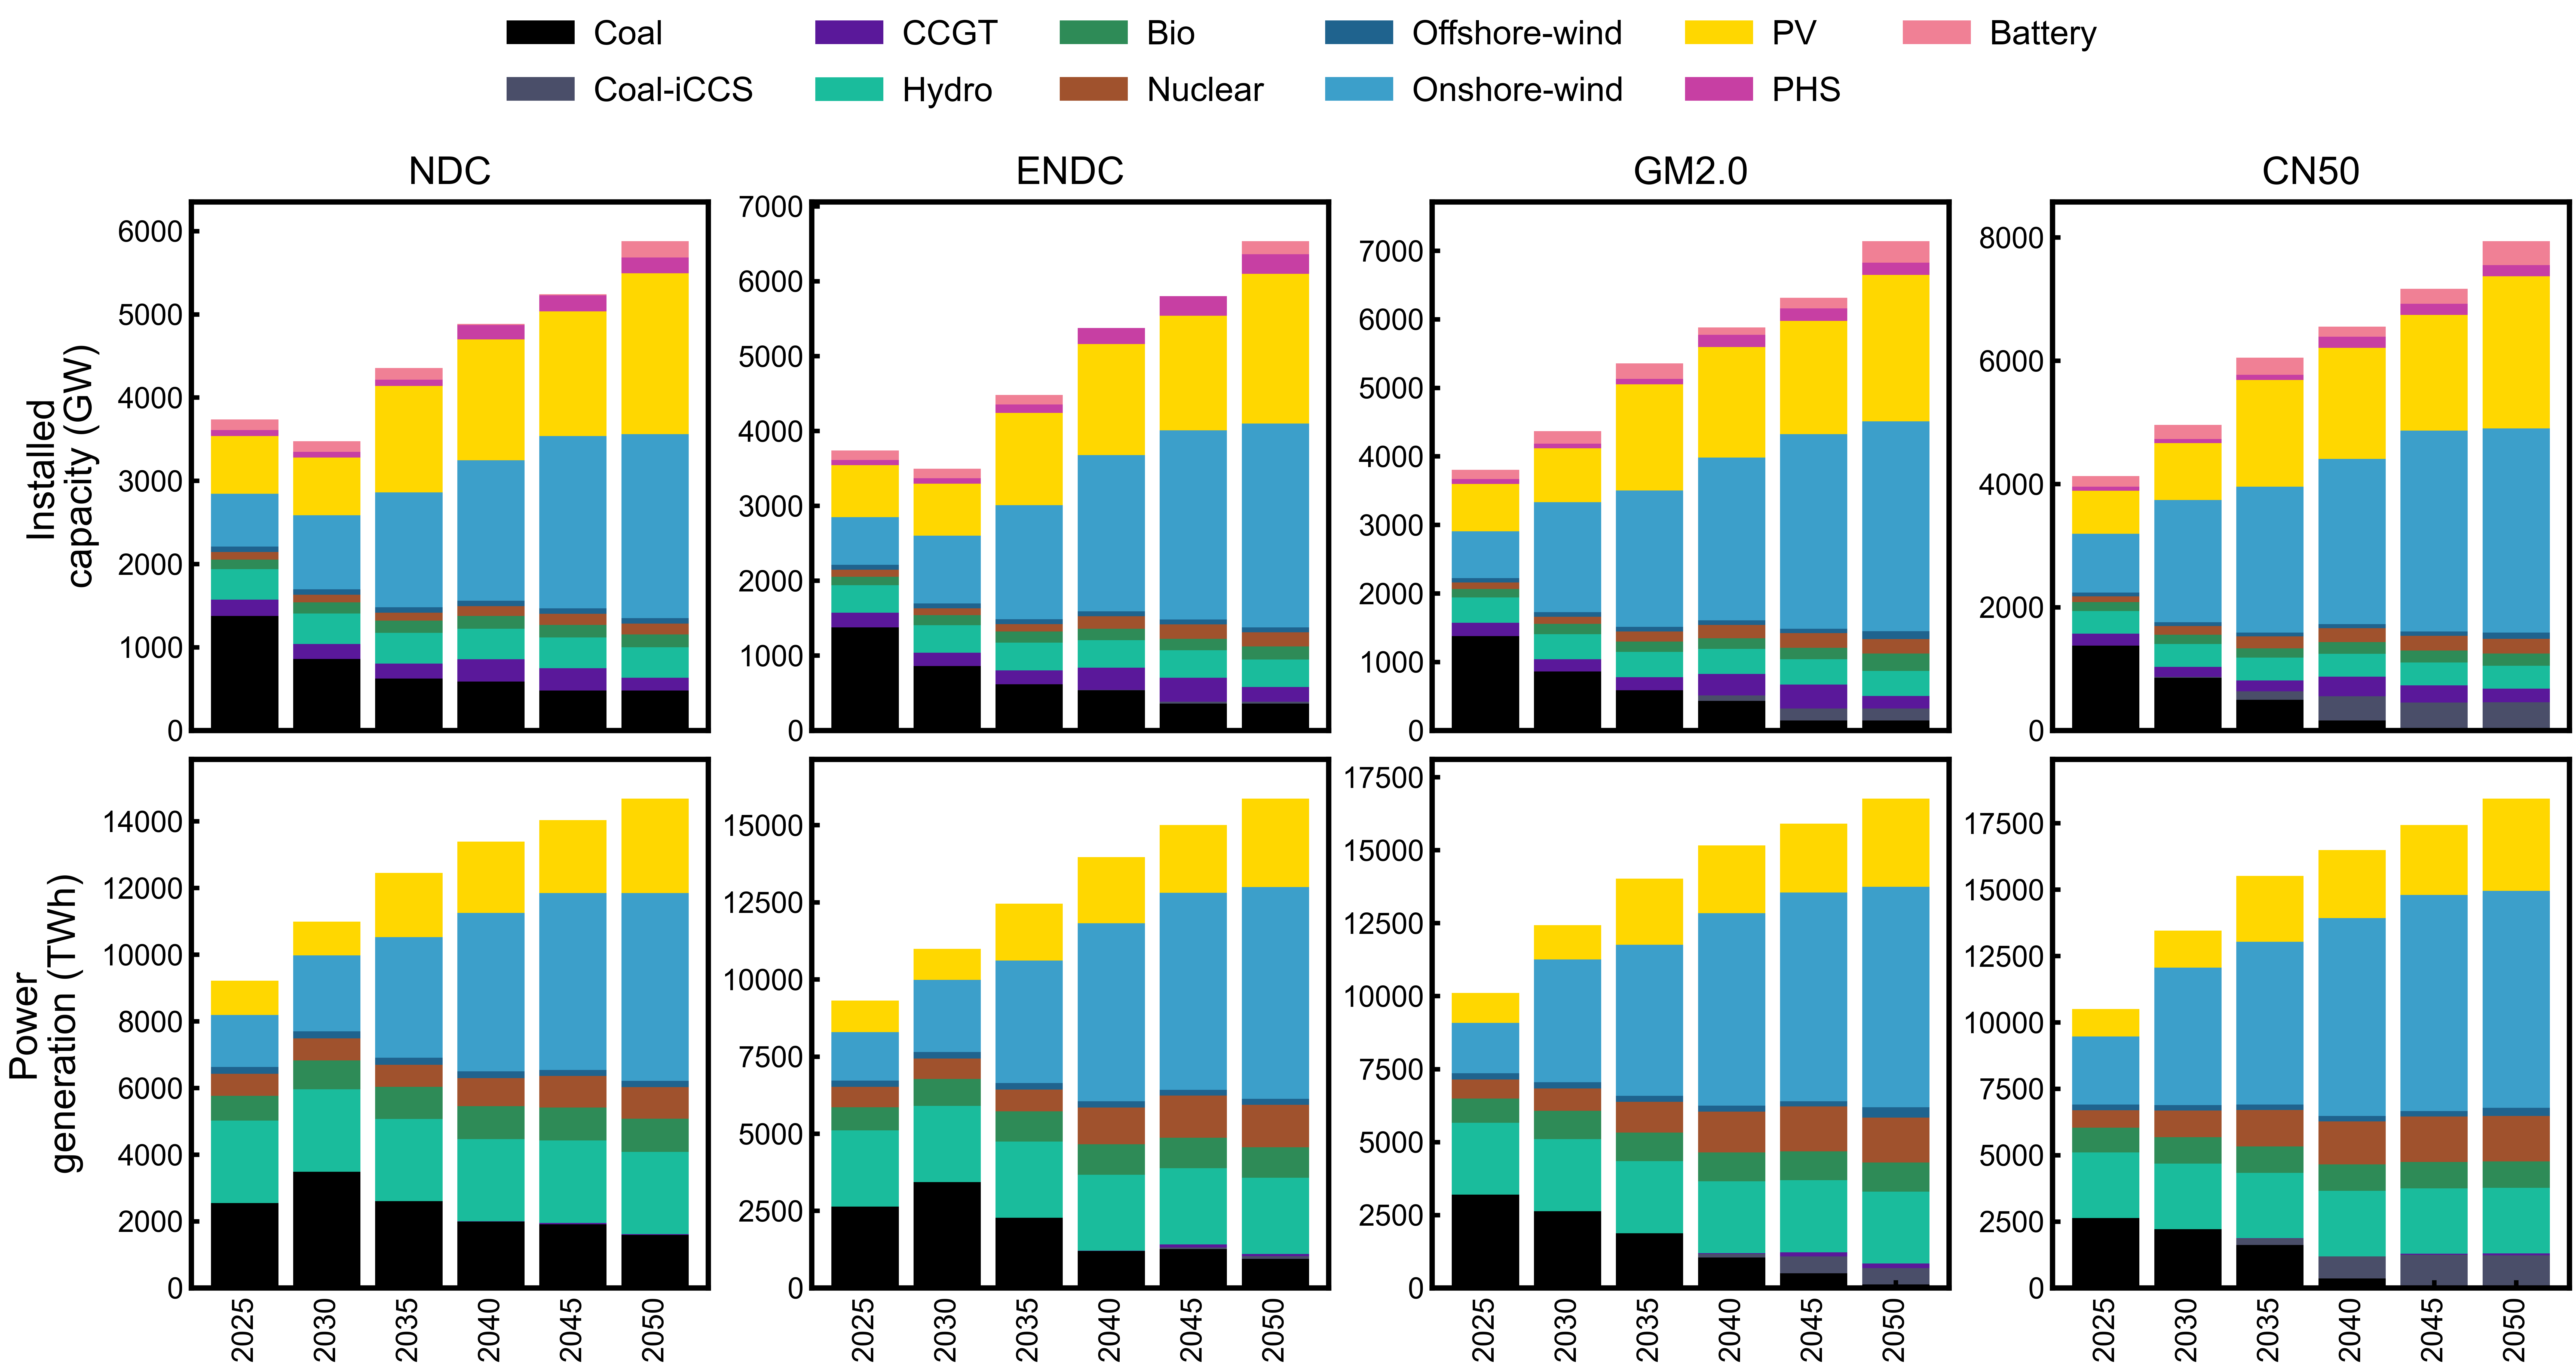

Figure saved to: Cap_Gen_4cases.png


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Image

cap_path = "Cap_4cases.xlsx"
gen_path = "Gen_4cases.xlsx"
output_png = "Cap_Gen_4cases.png"

cases = ["NDC", "ENDC", "GM2.0", "CN50"]

plot_order = [
    "coal", "coics", "gtcc", "hydo", "bio", "nu",
    "fwd", "nwd", "pv", "phs", "lib4", "imports"
]

colors = {
    "coal": "#000000",
    "coics": "#4a4e69",
    "gtcc": "#5a189a",
    "nu": "sienna",
    "hydo": "#1ABC9C",
    "bio": "seagreen",
    "fwd": "#1f638e",
    "nwd": "#3C9FCA",
    "pv": "gold",
    "phs": "#C73FA3",
    "lib4": "#F08095"
}

legend_names = {
    "coal": "Coal",
    "coics": "Coal-iCCS",
    "gtcc": "CCGT",
    "nu": "Nuclear",
    "hydo": "Hydro",
    "bio": "Bio",
    "fwd": "Offshore-wind",
    "nwd": "Onshore-wind",
    "pv": "PV",
    "phs": "PHS",
    "lib4": "Battery"
    }

tech_alias = {
    "coal-iccs": "coics",
    "coal_iccs": "coics",
    "coal+ccs": "coics",
    "ccgt": "gtcc",
    "gas": "gtcc",
    "nuclear": "nu",
    "hydro": "hydo",
    "hydropower": "hydo",
    "offshore-wind": "fwd",
    "offshore wind": "fwd",
    "onshore-wind": "nwd",
    "onshore wind": "nwd",
    "battery": "lib4",
    "bat": "lib4",
}

def read_case_workbook(path, cases):
    xls = pd.ExcelFile(path)
    data_dict = {}

    for case in cases:
        if case not in xls.sheet_names:
            raise ValueError(f"Sheet '{case}' is missing in {path}. Existing sheets: {xls.sheet_names}")

        raw = pd.read_excel(path, sheet_name=case)
        raw = raw.dropna(how="all").dropna(axis=1, how="all")

        tech_col = raw.columns[0]
        raw[tech_col] = (
            raw[tech_col]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace(tech_alias)
        )

        raw = raw.set_index(tech_col)
        raw.index.name = "technology"
        raw = raw.apply(pd.to_numeric, errors="coerce").fillna(0.0)

        new_cols = []
        for c in raw.columns:
            try:
                new_cols.append(int(c))
            except Exception:
                new_cols.append(c)

        raw.columns = new_cols
        year_cols = sorted([c for c in raw.columns if isinstance(c, int)])
        raw = raw[year_cols]

        raw = raw.groupby(raw.index).sum()

        df = raw.T.copy()
        df.index = df.index.astype(int)

        data_dict[case] = df

    return data_dict

cap_data = read_case_workbook(cap_path, cases)
gen_data = read_case_workbook(gen_path, cases)

for dataset in (cap_data, gen_data):
    for case in cases:
        for tech in plot_order:
            if tech not in dataset[case].columns:
                dataset[case][tech] = 0.0
        dataset[case] = dataset[case][plot_order]

active_techs = []
for tech in plot_order:
    has_value = False
    for dataset in (cap_data, gen_data):
        for case in cases:
            if dataset[case][tech].abs().sum() > 0:
                has_value = True
                break
        if has_value:
            break
    if has_value:
        active_techs.append(tech)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.linewidth"] = 2.35
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 3.5
plt.rcParams["ytick.major.size"] = 3.5
plt.rcParams["xtick.major.width"] = 2
plt.rcParams["ytick.major.width"] = 2

def draw_stacked_bar(ax, df, techs, show_xticks=True, ylabel=None, title=None):
    x = np.arange(len(df.index))
    bottom = np.zeros(len(df.index))

    for tech in techs:
        vals = df[tech].to_numpy(dtype=float)
        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.82,
            color=colors[tech],
            edgecolor="none",
            linewidth=0,
        )
        bottom += vals

    ax.set_xlim(-0.65, len(df.index) - 0.35)

    ymax = float(bottom.max()) if len(bottom) else 1.0
    ax.set_ylim(0, ymax * 1.08 if ymax > 0 else 1.0)

    ax.set_xticks(x)

    if show_xticks:
        ax.set_xticklabels([str(y) for y in df.index], rotation=90, fontsize=13)
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", length=0)

    ax.tick_params(axis="y", labelsize=13)
    ax.grid(False)

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=17, labelpad=8)
    else:
        ax.set_ylabel("")

    if title is not None:
        ax.set_title(title, fontsize=17, pad=8)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.35)
        spine.set_color("black")

fig, axes = plt.subplots(2, 4, figsize=(16, 9.3), dpi=300)

for j, case in enumerate(cases):
    draw_stacked_bar(
        axes[0, j],
        cap_data[case],
        active_techs,
        show_xticks=False,
        ylabel="Installed\ncapacity (GW)" if j == 0 else None,
        title=case,
    )

    draw_stacked_bar(
        axes[1, j],
        gen_data[case],
        active_techs,
        show_xticks=True,
        ylabel="Power\ngeneration (TWh)" if j == 0 else None,
        title=None,
    )

legend_handles = [
    Patch(facecolor=colors[t], edgecolor="none", label=legend_names[t])
    for t in active_techs
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    ncol=6,
    frameon=False,
    fontsize=15,
    handlelength=2.0,
    handletextpad=0.55,
    columnspacing=1.8,
    labelspacing=0.75,
)

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.105,
    top=0.82,
    wspace=0.20,
    hspace=0.055,
)

fig.savefig(output_png, dpi=600, bbox_inches="tight", pad_inches=0.04)
plt.show()

display(Image(filename=output_png))
print(f"Figure saved to: {output_png}")